In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import joblib, os

df = pd.read_csv('../data/clean_matches.csv')
df2 = df.dropna(subset=['winner']).copy()

le_cat   = LabelEncoder()
le_round = LabelEncoder()
le_court = LabelEncoder()
le_src   = LabelEncoder()

df2['category_enc']   = le_cat.fit_transform(df2['category'])
df2['round_name_enc'] = le_round.fit_transform(df2['round_name'])
df2['court_enc']      = le_court.fit_transform(df2['court'].fillna('Unknown'))
df2['source_enc']     = le_src.fit_transform(df2['competition_source'])
df2['winner_enc']     = (df2['winner'] == 'team_1').astype(int)
df2['duration_filled']= df2['duration_minutes'].fillna(df2['duration_minutes'].median())
df2['played_at']      = pd.to_datetime(df2['played_at'], errors='coerce')
df2['month']          = df2['played_at'].dt.month.fillna(0).astype(int)

FEATURES = ['category_enc', 'round', 'round_name_enc', 'index',
            'court_enc', 'source_enc', 'month', 'winner_enc', 'duration_filled']

X = df2[FEATURES]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Données prêtes:", X_scaled.shape)

✅ Données prêtes: (1144, 9)


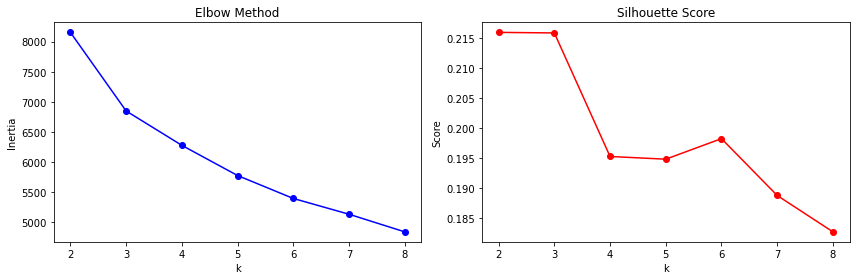

Silhouette scores: {2: 0.216, 3: 0.216, 4: 0.195, 5: 0.195, 6: 0.198, 7: 0.189, 8: 0.183}


In [2]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k'); ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()
print("Silhouette scores:", dict(zip(K_range, [round(s,3) for s in sil_scores])))

In [3]:
# Choix du meilleur k (celui avec le meilleur silhouette)
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"Meilleur k: {best_k}")

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df2['cluster_kmeans'] = km_best.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=5)
df2['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(df2['cluster_dbscan'])) - (1 if -1 in df2['cluster_dbscan'].values else 0)
print(f"DBSCAN clusters: {n_clusters_db} | Bruit: {(df2['cluster_dbscan']==-1).sum()} points")

Meilleur k: 2
DBSCAN clusters: 19 | Bruit: 102 points


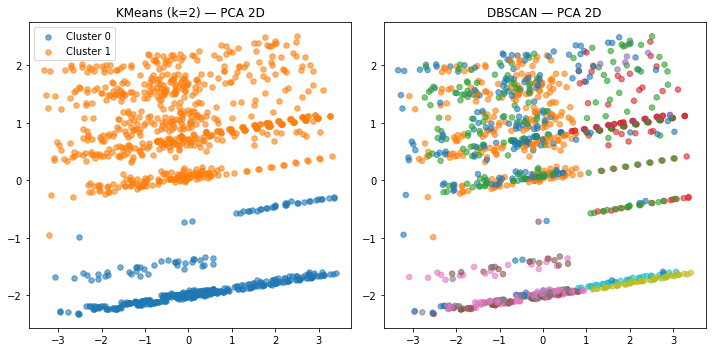

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
for c in sorted(df2['cluster_kmeans'].unique()):
    mask = df2['cluster_kmeans'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.6, s=30)
plt.title(f'KMeans (k={best_k}) — PCA 2D')
plt.legend()

plt.subplot(1,2,2)
colors = df2['cluster_dbscan'].map(lambda x: 'grey' if x == -1 else f'C{x}')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df2['cluster_dbscan'], cmap='tab10', alpha=0.6, s=30)
plt.title('DBSCAN — PCA 2D')
plt.tight_layout()
plt.show()

In [5]:
os.makedirs('../models', exist_ok=True)
joblib.dump(km_best,  '../models/kmeans_matches.pkl')
joblib.dump(pca,      '../models/pca_matches.pkl')
joblib.dump(scaler,   '../models/scaler_matches.pkl')
df2.to_csv('../data/matches_clustered.csv', index=False)
print("✅ Clustering sauvegardé !")

✅ Clustering sauvegardé !


In [ ]:
✅ Données prêtes: (1144, 9)
Silhouette scores: {2: 0.216, 3: 0.216, 4: 0.195, 5: 0.195, 6: 0.198, 7: 0.189, 8: 0.183}Meilleur k: 2
DBSCAN clusters: 19 | Bruit: 102 points ✅ Clustering sauvegardé !
